# Лабораторная работа № 2

### ОПТИМАЛЬНЫЕ СТРАТЕГИИ ТЕОРИИ СТАТИСТИЧЕСКОГО РАСПОЗНАВАНИЯ ОБРАЗОВ

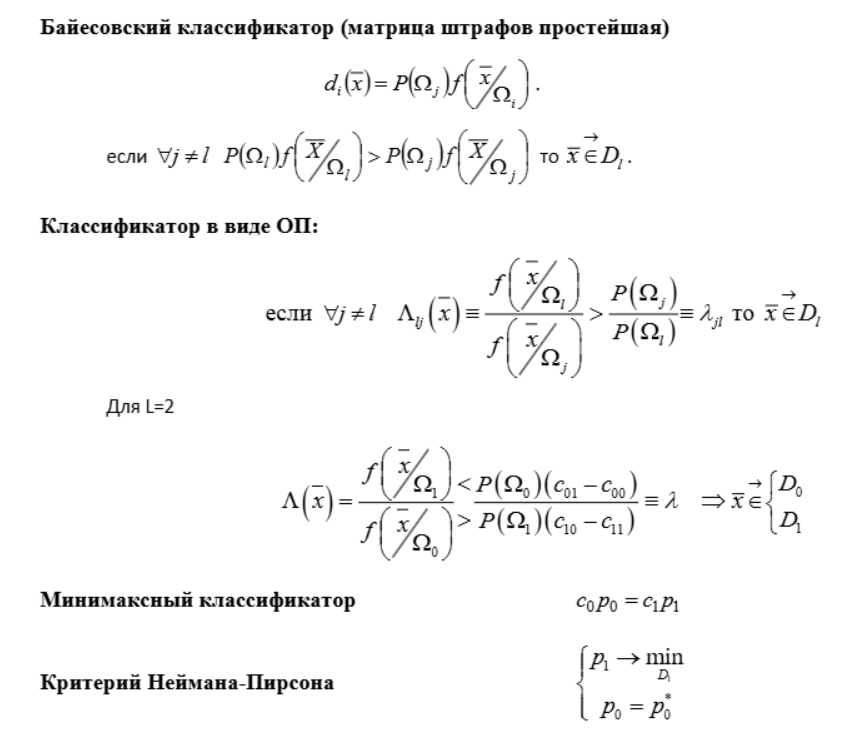

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

In [21]:
M1 = np.array([-1.0,  1.0])
M2 = np.array([ 0.0, -1.0])
M3 = np.array([ 2.0, -1.0])

B_equal = np.array([
    [0.16 , 0.032],
    [0.032, 0.16 ]
])

B1 = np.array([
    [0.04, 0.08],
    [0.08, 0.64]
])

B2 = np.array([
    [ 0.49  , -0.105 ],
    [-0.105 ,  0.0625]
])

B3 = np.array([
    [0.2025  , 0.010125],
    [0.010125, 0.2025  ]
])

X_eq_1 = np.load("gauss_step2_class1.npy")
X_eq_2 = np.load("gauss_step2_class2.npy")

X_neq_1 = np.load("gauss_step3_class1.npy")
X_neq_2 = np.load("gauss_step3_class2.npy")
X_neq_3 = np.load("gauss_step3_class3.npy")

In [22]:
print("M1 =", M1)
print("M2 =", M2)
print("M3 =", M3)

print("\nB_equal =\n", B_equal)
print("\nB1 =\n", B1)
print("\nB2 =\n", B2)
print("\nB3 =\n", B3)

M1 = [-1.  1.]
M2 = [ 0. -1.]
M3 = [ 2. -1.]

B_equal =
 [[0.16  0.032]
 [0.032 0.16 ]]

B1 =
 [[0.04 0.08]
 [0.08 0.64]]

B2 =
 [[ 0.49   -0.105 ]
 [-0.105   0.0625]]

B3 =
 [[0.2025   0.010125]
 [0.010125 0.2025  ]]


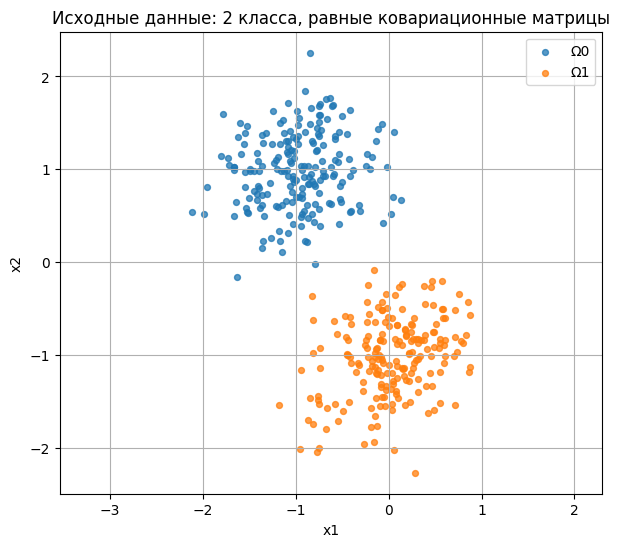

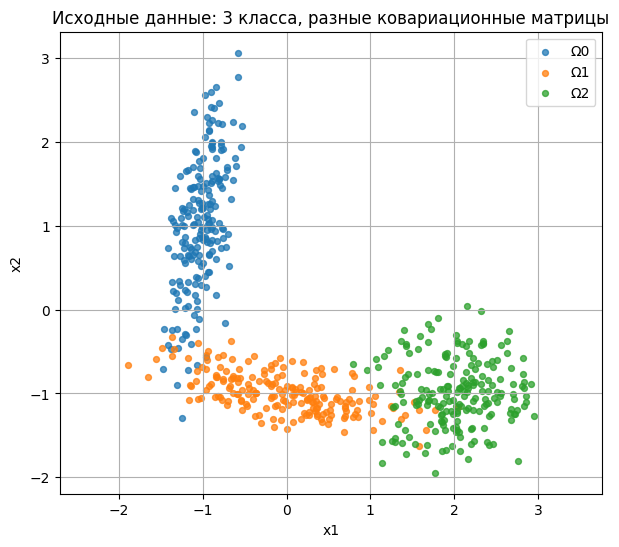

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(X_eq_1[:, 0], X_eq_1[:, 1], s=18, alpha=0.75, label='Ω0')
plt.scatter(X_eq_2[:, 0], X_eq_2[:, 1], s=18, alpha=0.75, label='Ω1')
plt.title('Исходные данные: 2 класса, равные ковариационные матрицы')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(X_neq_1[:, 0], X_neq_1[:, 1], s=18, alpha=0.75, label='Ω0')
plt.scatter(X_neq_2[:, 0], X_neq_2[:, 1], s=18, alpha=0.75, label='Ω1')
plt.scatter(X_neq_3[:, 0], X_neq_3[:, 1], s=18, alpha=0.75, label='Ω2')
plt.title('Исходные данные: 3 класса, разные ковариационные матрицы')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

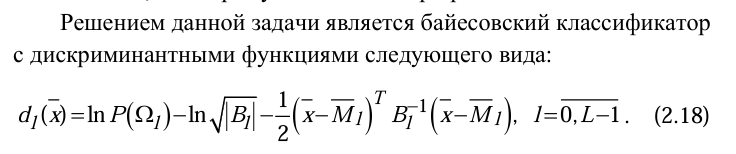

In [24]:
def gaussian_discriminant(X, M, B, prior=0.5):
    X = np.atleast_2d(X)
    B_inv = np.linalg.inv(B)
    det_B = np.linalg.det(B)

    diff = X - M
    quad = np.sum((diff @ B_inv) * diff, axis=1)

    return np.log(prior) - np.log(np.sqrt(det_B)) - 0.5 * quad

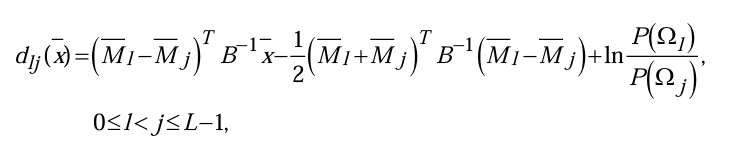

In [25]:
def decision_equal_cov(X, M0, M1, B, lambda_thr=1.0, P0=0.5, P1=0.5):
    X = np.atleast_2d(X)
    B_inv = np.linalg.inv(B)

    a = B_inv @ (M1 - M0)
    b = -0.5 * (M1 + M0).T @ B_inv @ (M1 - M0) + np.log(P1 / P0) - np.log(lambda_thr)

    return X @ a + b

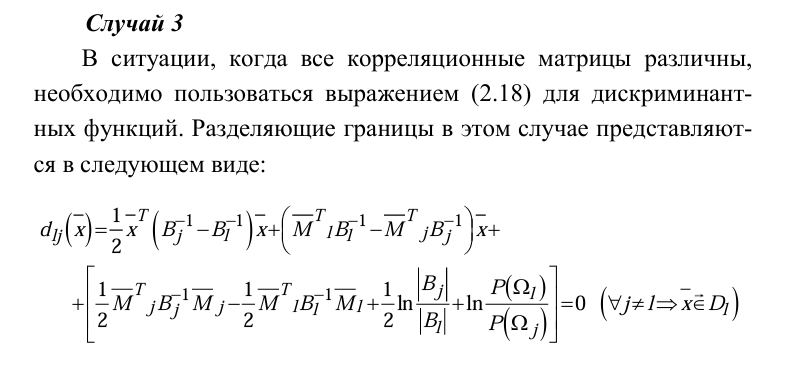

In [26]:
def decision_general(X, M0, B0, M1, B1, P0=0.5, P1=0.5):
    g0 = gaussian_discriminant(X, M0, B0, prior=P0)
    g1 = gaussian_discriminant(X, M1, B1, prior=P1)
    return g1 - g0

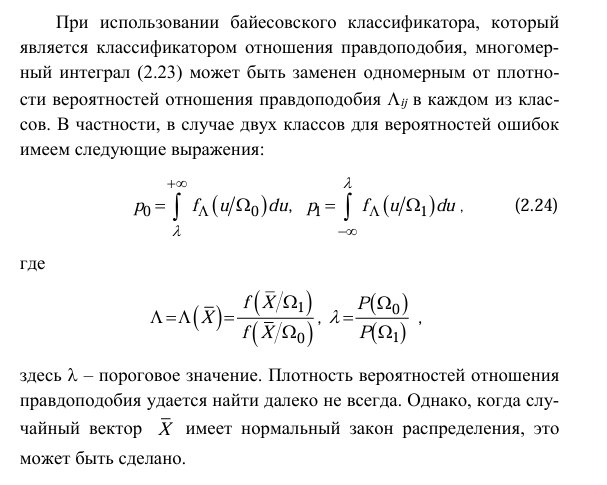

In [27]:
def experimental_errors(X0, X1, score_func):
    s0 = score_func(X0)
    s1 = score_func(X1)

    p0_err = np.mean(s0 > 0)
    p1_err = np.mean(s1 <= 0)
    p_sum = 0.5 * (p0_err + p1_err)

    return p0_err, p1_err, p_sum

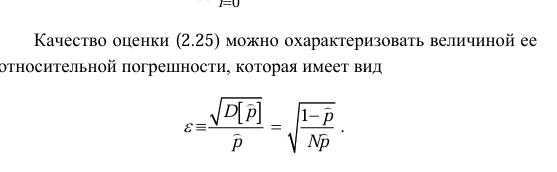

In [28]:
def relative_error_estimate(p_hat, N):
    if p_hat <= 0:
        return np.inf
    return np.sqrt((1 - p_hat) / (N * p_hat))


def required_sample_size(p, rel_eps=0.05):
    if p <= 0:
        return np.inf
    return int(np.ceil((1 - p) / (p * rel_eps**2)))

In [29]:
def plot_binary_boundary(score_func, X_list, labels, colors, title, levels=[0]):
    allX = np.vstack(X_list)

    x_min, x_max = allX[:, 0].min() - 1.0, allX[:, 0].max() + 1.0
    y_min, y_max = allX[:, 1].min() - 1.0, allX[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = score_func(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    for X, lab, c in zip(X_list, labels, colors):
        plt.scatter(X[:, 0], X[:, 1], s=18, alpha=0.75, label=lab, color=c)

    cs = plt.contour(xx, yy, zz, levels=levels, colors='black', linewidths=2)
    plt.clabel(cs, inline=True, fontsize=10)

    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()


def plot_three_class_regions(X1, X2, X3, M1, B1, M2, B2, M3, B3, title):
    allX = np.vstack([X1, X2, X3])
    x_min, x_max = allX[:, 0].min() - 1.0, allX[:, 0].max() + 1.0
    y_min, y_max = allX[:, 1].min() - 1.0, allX[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    g1 = gaussian_discriminant(grid, M1, B1, prior=1/3)
    g2 = gaussian_discriminant(grid, M2, B2, prior=1/3)
    g3 = gaussian_discriminant(grid, M3, B3, prior=1/3)

    cls = np.argmax(np.column_stack([g1, g2, g3]), axis=1).reshape(xx.shape)

    plt.figure(figsize=(8, 7))
    plt.contourf(xx, yy, cls, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.25)

    plt.scatter(X1[:, 0], X1[:, 1], s=18, alpha=0.75, label='Ω0')
    plt.scatter(X2[:, 0], X2[:, 1], s=18, alpha=0.75, label='Ω1')
    plt.scatter(X3[:, 0], X3[:, 1], s=18, alpha=0.75, label='Ω2')

    d12 = (g2 - g1).reshape(xx.shape)
    d13 = (g3 - g1).reshape(xx.shape)
    d23 = (g3 - g2).reshape(xx.shape)

    plt.contour(xx, yy, d12, levels=[0], colors='black', linewidths=2)
    plt.contour(xx, yy, d13, levels=[0], colors='purple', linewidths=2)
    plt.contour(xx, yy, d23, levels=[0], colors='orange', linewidths=2)

    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()

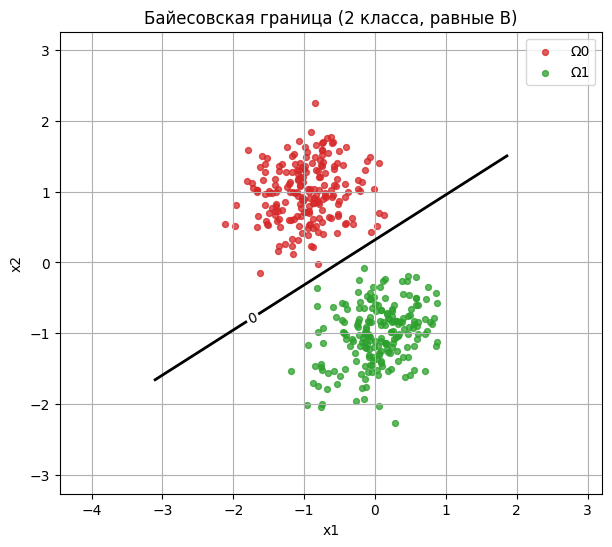

In [30]:
score_bayes_eq = lambda X: decision_equal_cov(
    X, M1, M2, B_equal,
    lambda_thr=1.0,
    P0=0.5, P1=0.5
)

plot_binary_boundary(
    score_bayes_eq,
    [X_eq_1, X_eq_2],
    labels=['Ω0', 'Ω1'],
    colors=['tab:red', 'tab:green'],
    title='Байесовская граница (2 класса, равные B)'
)

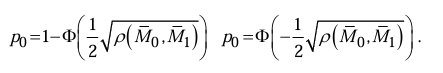

In [31]:
p0_bayes, p1_bayes, p_sum_bayes = experimental_errors(X_eq_1, X_eq_2, score_bayes_eq)

rho_M = (M2 - M1).T @ np.linalg.inv(B_equal) @ (M2 - M1)

p0_theor = 1 - norm.cdf(0.5 * np.sqrt(rho_M))
p1_theor = norm.cdf(-0.5 * np.sqrt(rho_M))
p_sum_theor = 0.5 * (p0_theor + p1_theor)

print("Байесовский классификатор")
print(f"rho_M = {rho_M:.6f}")

print("\nТеоретические вероятности ошибок:")
print(f"p0_theor = {p0_theor:.6f}")
print(f"p1_theor = {p1_theor:.6f}")
print(f"pΣ_theor = {p_sum_theor:.6f}")

print("\nЭкспериментальные вероятности ошибок:")
print(f"p0_exp = {p0_bayes:.6f}")
print(f"p1_exp = {p1_bayes:.6f}")
print(f"pΣ_exp = {p_sum_bayes:.6f}")

Байесовский классификатор
rho_M = 37.760417

Теоретические вероятности ошибок:
p0_theor = 0.001061
p1_theor = 0.001061
pΣ_theor = 0.001061

Экспериментальные вероятности ошибок:
p0_exp = 0.000000
p1_exp = 0.000000
pΣ_exp = 0.000000


In [32]:
# Минимаксный классификатор
lambda_minimax = 1.0
score_minimax = lambda X: decision_equal_cov(
    X, M1, M2, B_equal,
    lambda_thr=lambda_minimax,
    P0=0.5, P1=0.5
)

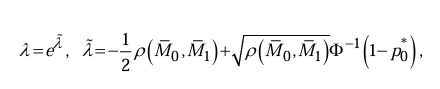

In [33]:
# Классификатор Неймана–Пирсона
alpha = 0.05

rho_M = (M2 - M1).T @ np.linalg.inv(B_equal) @ (M2 - M1)

ln_lambda_np = -0.5 * rho_M + np.sqrt(rho_M) * norm.ppf(1 - alpha)
lambda_np = np.exp(ln_lambda_np)

score_np = lambda X: decision_equal_cov(
    X, M1, M2, B_equal,
    lambda_thr=lambda_np,
    P0=0.5, P1=0.5
)

print(f"lambda_minimax = {lambda_minimax:.6f}")
print(f"lambda_NP = {lambda_np:.6f}")

lambda_minimax = 1.000000
lambda_NP = 0.000155


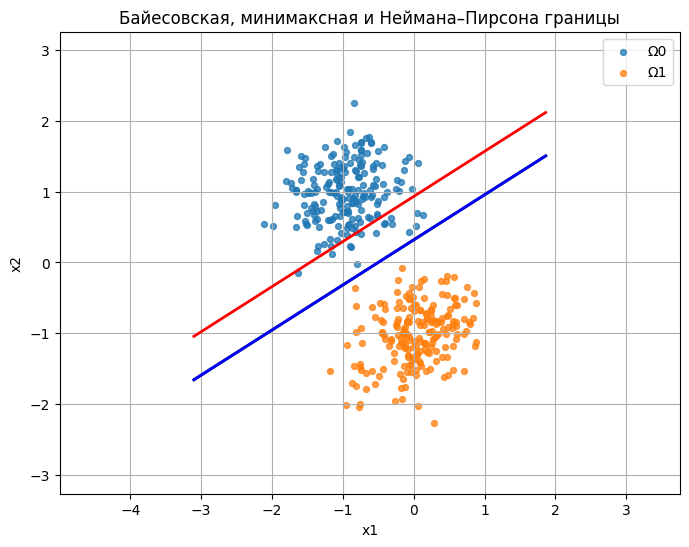

In [34]:
allX = np.vstack([X_eq_1, X_eq_2])
x_min, x_max = allX[:, 0].min() - 1.0, allX[:, 0].max() + 1.0
y_min, y_max = allX[:, 1].min() - 1.0, allX[:, 1].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)
grid = np.column_stack([xx.ravel(), yy.ravel()])

zz_bayes = score_bayes_eq(grid).reshape(xx.shape)
zz_minimax = score_minimax(grid).reshape(xx.shape)
zz_np = score_np(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X_eq_1[:, 0], X_eq_1[:, 1], s=18, alpha=0.75, label='Ω0')
plt.scatter(X_eq_2[:, 0], X_eq_2[:, 1], s=18, alpha=0.75, label='Ω1')

plt.contour(xx, yy, zz_bayes, levels=[0], colors='black', linewidths=2)
plt.contour(xx, yy, zz_minimax, levels=[0], colors='blue', linewidths=2)
plt.contour(xx, yy, zz_np, levels=[0], colors='red', linewidths=2)

plt.title('Байесовская, минимаксная и Неймана–Пирсона границы')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

In [35]:
p0_mm, p1_mm, p_sum_mm = experimental_errors(X_eq_1, X_eq_2, score_minimax)
p0_np, p1_np, p_sum_np = experimental_errors(X_eq_1, X_eq_2, score_np)

print("Минимаксный классификатор:")
print(f"p0 = {p0_mm:.6f}")
print(f"p1 = {p1_mm:.6f}")
print(f"pΣ = {p_sum_mm:.6f}")

print("\nКлассификатор Неймана–Пирсона:")
print(f"p0 = {p0_np:.6f}")
print(f"p1 = {p1_np:.6f}")
print(f"pΣ = {p_sum_np:.6f}")

Минимаксный классификатор:
p0 = 0.000000
p1 = 0.000000
pΣ = 0.000000

Классификатор Неймана–Пирсона:
p0 = 0.075000
p1 = 0.000000
pΣ = 0.037500


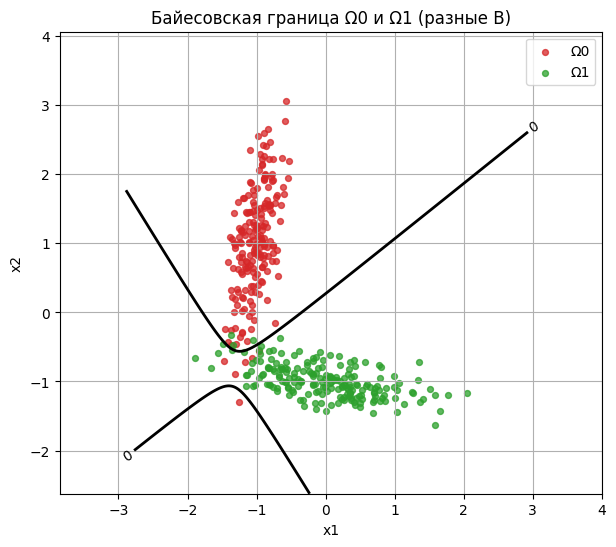

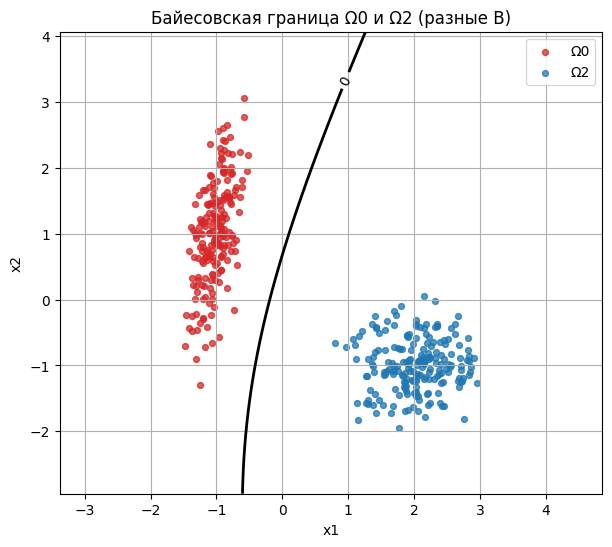

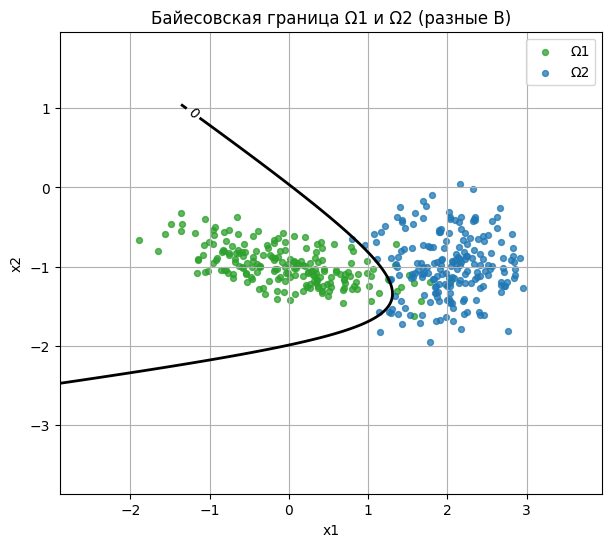

In [36]:
score_01 = lambda X: decision_general(X, M1, B1, M2, B2, P0=0.5, P1=0.5)
score_02 = lambda X: decision_general(X, M1, B1, M3, B3, P0=0.5, P1=0.5)
score_12 = lambda X: decision_general(X, M2, B2, M3, B3, P0=0.5, P1=0.5)

plot_binary_boundary(
    score_01,
    [X_neq_1, X_neq_2],
    labels=['Ω0', 'Ω1'],
    colors=['tab:red', 'tab:green'],
    title='Байесовская граница Ω0 и Ω1 (разные B)'
)

plot_binary_boundary(
    score_02,
    [X_neq_1, X_neq_3],
    labels=['Ω0', 'Ω2'],
    colors=['tab:red', 'tab:blue'],
    title='Байесовская граница Ω0 и Ω2 (разные B)'
)

plot_binary_boundary(
    score_12,
    [X_neq_2, X_neq_3],
    labels=['Ω1', 'Ω2'],
    colors=['tab:green', 'tab:blue'],
    title='Байесовская граница Ω1 и Ω2 (разные B)'
)

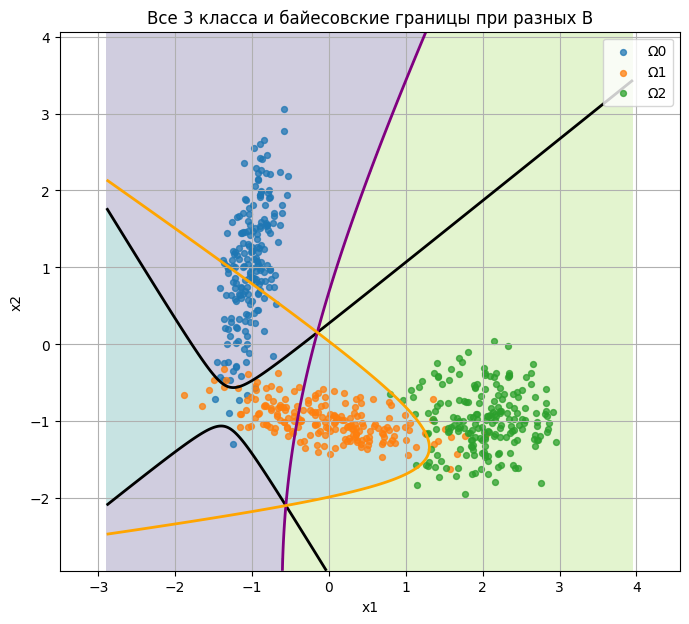

In [37]:
plot_three_class_regions(
    X_neq_1, X_neq_2, X_neq_3,
    M1, B1, M2, B2, M3, B3,
    title='Все 3 класса и байесовские границы при разных B'
)

In [38]:
pairs = [
    ("Ω0 vs Ω1", X_neq_1, X_neq_2, score_01),
    ("Ω0 vs Ω2", X_neq_1, X_neq_3, score_02),
    ("Ω1 vs Ω2", X_neq_2, X_neq_3, score_12),
]

for name, XA, XB, score_func in pairs:
    p0, p1, ps = experimental_errors(XA, XB, score_func)
    N_current = len(XA)

    print("=" * 55)
    print(name)
    print(f"Ошибка 1 рода p0 = {p0:.6f}")
    print(f"Ошибка 2 рода p1 = {p1:.6f}")
    print(f"Суммарная ошибка pΣ = {ps:.6f}")

    eps0 = relative_error_estimate(p0, N_current)
    eps1 = relative_error_estimate(p1, N_current)
    epss = relative_error_estimate(ps, N_current)

    print(f"Относительная погрешность eps_rel(p0) = {eps0*100 if np.isfinite(eps0) else np.inf:.2f}%")
    print(f"Относительная погрешность eps_rel(p1) = {eps1*100 if np.isfinite(eps1) else np.inf:.2f}%")
    print(f"Относительная погрешность eps_rel(pΣ) = {epss*100 if np.isfinite(epss) else np.inf:.2f}%")

    n0 = required_sample_size(p0, 0.05)
    n1 = required_sample_size(p1, 0.05)
    ns = required_sample_size(ps, 0.05)

    print(f"N для eps<=5% по p0: {n0}")
    print(f"N для eps<=5% по p1: {n1}")
    print(f"N для eps<=5% по pΣ: {ns}")

Ω0 vs Ω1
Ошибка 1 рода p0 = 0.025000
Ошибка 2 рода p1 = 0.015000
Суммарная ошибка pΣ = 0.020000
Относительная погрешность eps_rel(p0) = 44.16%
Относительная погрешность eps_rel(p1) = 57.30%
Относительная погрешность eps_rel(pΣ) = 49.50%
N для eps<=5% по p0: 15600
N для eps<=5% по p1: 26267
N для eps<=5% по pΣ: 19600
Ω0 vs Ω2
Ошибка 1 рода p0 = 0.000000
Ошибка 2 рода p1 = 0.000000
Суммарная ошибка pΣ = 0.000000
Относительная погрешность eps_rel(p0) = inf%
Относительная погрешность eps_rel(p1) = inf%
Относительная погрешность eps_rel(pΣ) = inf%
N для eps<=5% по p0: inf
N для eps<=5% по p1: inf
N для eps<=5% по pΣ: inf
Ω1 vs Ω2
Ошибка 1 рода p0 = 0.055000
Ошибка 2 рода p1 = 0.010000
Суммарная ошибка pΣ = 0.032500
Относительная погрешность eps_rel(p0) = 29.31%
Относительная погрешность eps_rel(p1) = 70.36%
Относительная погрешность eps_rel(pΣ) = 38.58%
N для eps<=5% по p0: 6873
N для eps<=5% по p1: 39600
N для eps<=5% по pΣ: 11908
